In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy import sparse
from scipy.spatial import ConvexHull
import math  
import sklearn.metrics 
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Resumen

1. Crear la matriz de usuarios/películas
2. Normalización de los datos
3. Determinar la mejor K
4. Implementación Kmeans
5. Visualización de los clúster
6. Predicciones de prueba
7. Evaluación
8. Integración de la matriz simulada por factorización ponderada de matrices (WMF)

## 1. Crear la matriz usuarios/películas

In [9]:
df = pd.read_csv("BBDD_100K/ratings.csv")

indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
matriz_usuario_pelicula=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
matriz_usuario_pelicula.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Normalización

In [10]:
def normalizar_datos(matriz_escasez):
    matriz_escasez_copy = matriz_escasez.copy()
    scaler = StandardScaler(with_mean=True, with_std=True)
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy

matriz_normalizada = normalizar_datos(matriz_usuario_pelicula)
matriz_normalizada.head(20)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.458937,0.000000,-0.458937,0.000000,0.000000,-0.458937,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.371391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.596225,1.773677,-0.581226,1.773677,0.596225,0.596225,-0.581226,0.0,-0.581226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.958138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.442374,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.636784,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
def reescalar_predicciones(predicciones_normalizadas, matriz_usuario_pelicula, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar de cada usuario ignorando los NaNs originales
    medias_usuarios = matriz_usuario_pelicula.mean(axis=1, skipna=True)
    desviaciones_usuarios = matriz_usuario_pelicula.std(axis=1, skipna=True)
    # Aplicamos la transformación inversa sólo donde había datos originales
    predicciones_reescaladas = predicciones_normalizadas.mul(desviaciones_usuarios, axis=0).add(medias_usuarios, axis=0)
    predicciones_reescaladas = predicciones_reescaladas.where(~matriz_usuario_pelicula.isna(), np.nan)
    predicciones_reescaladas = predicciones_reescaladas.round()
    predicciones_reescaladas = predicciones_reescaladas.clip(lower=min_rating, upper=max_rating)
    
    return predicciones_reescaladas

In [12]:
matriz_reescalada_original = reescalar_predicciones(matriz_normalizada, matriz_usuario_pelicula)
matriz_reescalada_original.head(6)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Determinar la mejor K

Método del Codo: Evalúa la inercia (suma de las distancias cuadradas de las muestras a su centroide más cercano).

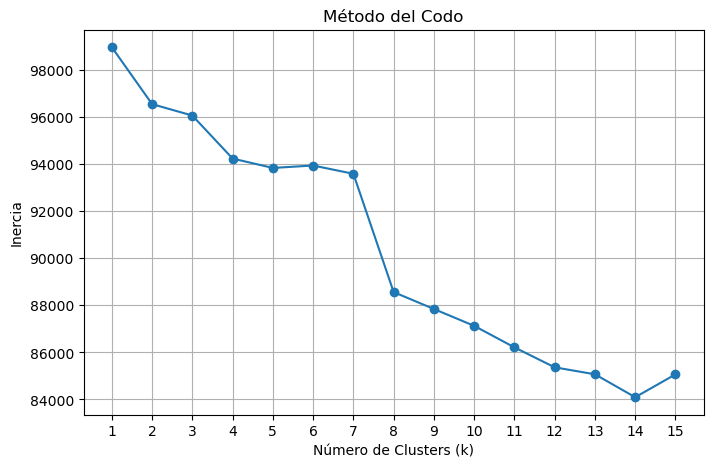

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def metodo_del_codo(matriz, max_k=15):
    '''
    Calcula y guarda el metodo del codo para diferentes valores de k.
    '''
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(matriz)
        inercia.append(kmeans.inertia_)
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.title('Método del Codo')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inercia')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()

metodo_del_codo(matriz_normalizada)


Observando la curva, parece que el "codo" ocurre alrededor de k = 8, donde la disminución de la inercia se vuelve menos pronunciada. Esto sugiere que 8 clústeres podría ser un valor razonable.

Silhouette Score: Mide qué tan cerca están los puntos de su clúster en comparación con otros clústeres.\
Es otra forma de mirar la k óptima, pero en este caso estamos teniendo en cuenta las distáncias, mientras que el método del Codo no se tienen en cuenta las distancias

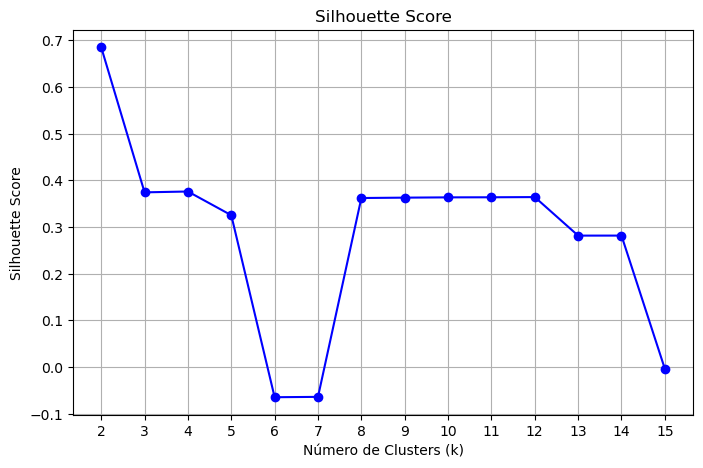

In [7]:
from sklearn.metrics import silhouette_score

def calcular_silhouette_score(matriz, min_k=2, max_k=15):
    '''
    Calcula y guarda el Silhouette Score para diferentes valores de k.
    '''
    silhouette_scores = []
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(matriz)
        score = silhouette_score(matriz, labels)
        silhouette_scores.append(score)
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_k, max_k + 1), silhouette_scores, marker='o', color='blue')
    plt.title('Silhouette Score')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(range(min_k, max_k + 1))
    plt.grid(True)
    plt.show()

calcular_silhouette_score(matriz_normalizada)

k=2 tiene el Silhouette Score más alto (0.6850), lo cual es típico porque agrupar todo en 2 clústeres maximiza la cohesión interna.

Sin embargo, después de k=2, el puntaje es más estable y ligeramente mejor en k=12 (0.3641), aunque las diferencias en los valores para k=8 a 12 son mínimas.

La elección entre k=2 (alta separación con menor granularidad) y k=12 (balance razonable) dependerá del nivel de detalle que se busque en las recomendaciones

Puesto que Tanto el método del codo como el de Silhouette coinden ambos en que K=8 es un buen candidato, `nos quedaremos con 8 clusters.`

# 4. Implementación de Kmeans

Lo primero que tenemos que hacer para implementar Kmeans es decidir que tipo de agrupación de clusteres vamos a realizar, si clusteres de usuarios similares, o clusteres de películas. En este caso como disponemos de menos usuarios que películas los clusteres serán de usuarios, esto se hace así porque 610 usuarios son mucho mas manejables que 9270 películas, Kmeans será mas eficiente y rápido con menos filas (usuarios) en la matriz.



Implementaré Kmeans con la distancia del Coseno, puesto que esta distancia no viene directamente con el Kmenas habrá que calcular la distancia de coseno a parte.

In [13]:
def calcular_distancia_coseno(matriz_normalizada, archivo_salida='distancia_coseno.npy'):
    if os.path.exists(archivo_salida):
        # Solamente si el archivo ya existe lo cargamos
        distancia_coseno = np.load(archivo_salida)
    else:
        # Calcular la similitud coseno y la distancia si el archivo no existe
        similitud_coseno = cosine_similarity(matriz_normalizada)
        distancia_coseno = 1 - similitud_coseno  # Convertir la similitud coseno en distancia coseno
        np.save(archivo_salida, distancia_coseno)
        print(f"Matriz de distancia coseno guardada en '{archivo_salida}'")
    return distancia_coseno

In [14]:
archivo_salida='distancia_coseno_100K.npy'
distancia_coseno = calcular_distancia_coseno(matriz_normalizada,archivo_salida)

In [15]:
modelo_kmeans = KMeans(n_clusters=8, random_state=42)
clusters_usuarios = modelo_kmeans.fit_predict(distancia_coseno)

###  Determinar la calidad del clúster

Ahora miraremos que la distribución de los clústeres sea correcta

In [8]:
# Contar el número de usuarios por cluster
distribucion_clusters = pd.DataFrame(clusters_usuarios, columns=['Cluster'])
print(distribucion_clusters['Cluster'].value_counts())

Cluster
5    118
6    105
3     89
1     88
7     88
2     60
0     40
4     22
Name: count, dtype: int64


Los clústeres parecen prometedores, pero vamos a ver las películas promedio más calificadas por los usuarios de cada clúster para ver si existen patrones específicos

In [10]:
# Agregar los clusters a la matriz normalizada
matriz_normalizada['cluster'] = clusters_usuarios

# Calcular la calificación promedio por cluster
peliculas_por_cluster = matriz_normalizada.groupby('cluster').mean()

# Mostrar las 5 películas más populares por cluster
for cluster in range(8):
    print(f"\nPelículas más populares en el cluster {cluster}:")
    print(peliculas_por_cluster.loc[cluster].sort_values(ascending=False).head(5))



Películas más populares en el cluster 0:
movieId
110    0.994783
318    0.854707
356    0.816204
457    0.785685
150    0.644245
Name: 0, dtype: float64

Películas más populares en el cluster 1:
movieId
260     0.825781
2571    0.561195
1196    0.535617
4993    0.501628
1198    0.498329
Name: 1, dtype: float64

Películas más populares en el cluster 2:
movieId
296    0.689634
593    0.655096
318    0.632916
356    0.624627
50     0.466312
Name: 2, dtype: float64

Películas más populares en el cluster 3:
movieId
60069    0.108852
2571     0.102586
4896     0.100946
8368     0.100171
5816     0.100102
Name: 3, dtype: float64

Películas más populares en el cluster 4:
movieId
593    1.314724
296    1.256327
318    1.143587
527    0.908327
356    0.848707
Name: 4, dtype: float64

Películas más populares en el cluster 5:
movieId
296     0.386359
858     0.376550
2858    0.284068
1193    0.262993
608     0.261445
Name: 5, dtype: float64

Películas más populares en el cluster 6:
movieId
356   

 La lista de películas más populares dentro de cada cluster refleja que los grupos tienen preferencias diferenciadas. Esto es un indicador de que el clustering está capturando patrones útiles para la personalización.

 Por ejemplo la película con el id 318 que correponde a "Shawshank Redemption, The (1994) con el genero de Crimen/Drama" demuestra ser puntuada de manera muy diferente dependiendo del clúster, esto da a entender que dependiendo del clúster también existe una preferencia u otra sobre los diferentes géneros que hay.

 A continuación vamos a visualizar esos clústeres:

# 5. Visualización de los clúster

In [123]:
def visualizar_pca(matriz_normalizada, clusters_usuarios):
    # Reducir la dimensionalidad a 2 componentes principales
    matriz_normalizada_visualizacion = matriz_normalizada.copy()
    matriz_normalizada_visualizacion.columns = matriz_normalizada_visualizacion.columns.astype(str)

    pca = PCA(n_components=2)
    matriz_reducida = pca.fit_transform(matriz_normalizada_visualizacion)

    df_clusters = pd.DataFrame({
        'Componente_1': matriz_reducida[:, 0],
        'Componente_2': matriz_reducida[:, 1],
        'Cluster': clusters_usuarios
    })
    umbral_x_min = -10
    umbral_x_max = 10
    umbral_y_min = -10
    umbral_y_max = 10


    df_clusters_filtrado = df_clusters[
        (df_clusters['Componente_1'] >= umbral_x_min) & 
        (df_clusters['Componente_1'] <= umbral_x_max) & 
        (df_clusters['Componente_2'] >= umbral_y_min) & 
        (df_clusters['Componente_2'] <= umbral_y_max)
    ]

    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 8))

    colores = sns.color_palette("tab10", len(df_clusters['Cluster'].unique()))
    for cluster, color in zip(sorted(df_clusters['Cluster'].unique()), colores):
        datos_cluster_filtrado = df_clusters_filtrado[df_clusters_filtrado['Cluster'] == cluster]
        puntos = datos_cluster_filtrado[['Componente_1', 'Componente_2']].values
    
        if len(puntos) > 2:  
            hull = ConvexHull(puntos)
            for simplex in hull.simplices:
                plt.plot(puntos[simplex, 0], puntos[simplex, 1], c=color, alpha=0.5, linestyle='--')
            plt.fill(puntos[hull.vertices, 0], puntos[hull.vertices, 1], color=color, alpha=0.2)
        
        plt.scatter(
            datos_cluster_filtrado['Componente_1'], 
            datos_cluster_filtrado['Componente_2'], 
            label=f'Cluster {cluster} ({len(df_clusters[df_clusters["Cluster"] == cluster])} usuarios)', 
            alpha=0.7, 
            color=color
        )
    centroides = df_clusters.groupby('Cluster')[['Componente_1', 'Componente_2']].mean()
    plt.scatter(
        centroides['Componente_1'], 
        centroides['Componente_2'], 
        s=100, 
        c='black', 
        marker='o', 
        label='Centroides'
    )
    plt.title('Visualización de Clusters (PCA)', fontsize=16, fontweight='bold')
    plt.xlabel('Componente Principal 1', fontsize=12)
    plt.ylabel('Componente Principal 2', fontsize=12)
    plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


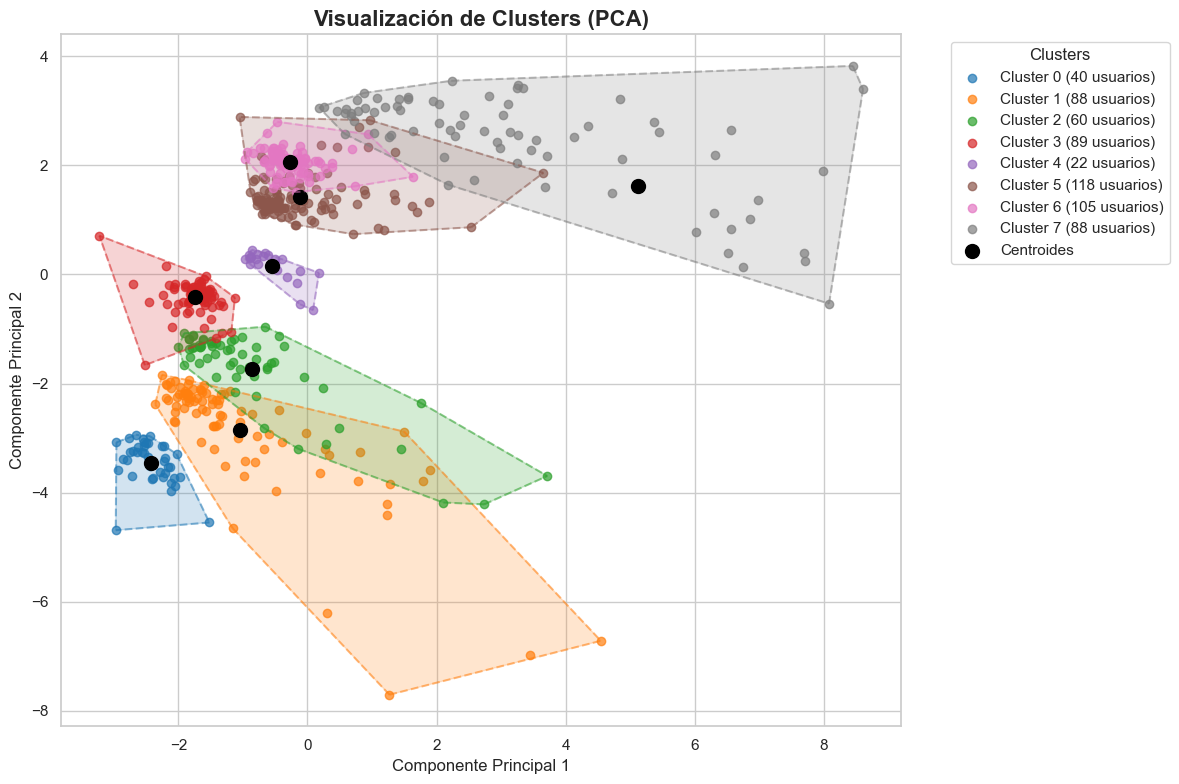

In [124]:
visualizar_pca(matriz_normalizada,clusters_usuarios)

En esta gráfica, los puntos representan a los usuarios proyectados en un espacio de 2 dimensiones utilizando los Componentes Principales. Los componentes principales son combinaciones lineales de las calificaciones originales que capturan la mayor parte de la variabilidad en los datos.

El Primer Componente Principal (PC1) explica la mayor cantidad de variación en las calificaciones, mientras que el Segundo Componente Principal (PC2) captura la siguiente mayor variabilidad, siendo ambos ortogonales entre sí. Los clusters muestran agrupaciones de usuarios con patrones similares de calificación, la distancia que existe entre estos a parte de por las calificaciones promedio puede ser debida a la preferencia de géneros

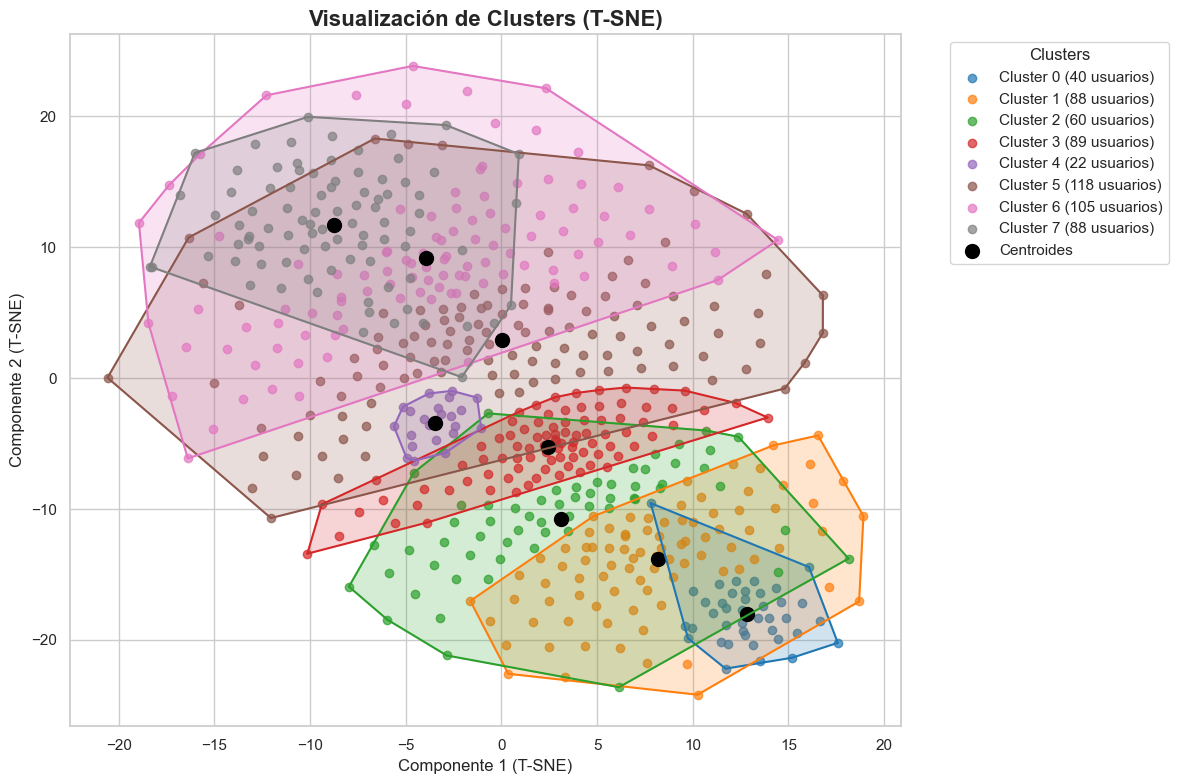

In [16]:
matriz_normalizada_visualizacion = matriz_normalizada.copy()
matriz_normalizada_visualizacion.columns = matriz_normalizada_visualizacion.columns.astype(str)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
matriz_reducida = tsne.fit_transform(matriz_normalizada_visualizacion)

df_clusters = pd.DataFrame({
    'Componente_1': matriz_reducida[:, 0],
    'Componente_2': matriz_reducida[:, 1],
    'Cluster': clusters_usuarios
})
umbral_x_min = -50
umbral_x_max = 50
umbral_y_min = -50
umbral_y_max = 50

df_clusters_filtrado = df_clusters[
    (df_clusters['Componente_1'] >= umbral_x_min) & 
    (df_clusters['Componente_1'] <= umbral_x_max) & 
    (df_clusters['Componente_2'] >= umbral_y_min) & 
    (df_clusters['Componente_2'] <= umbral_y_max)
]

sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
colores = sns.color_palette("tab10", len(df_clusters['Cluster'].unique()))
for cluster, color in zip(sorted(df_clusters['Cluster'].unique()), colores):
    datos_cluster_filtrado = df_clusters_filtrado[df_clusters_filtrado['Cluster'] == cluster]
    puntos = datos_cluster_filtrado[['Componente_1', 'Componente_2']].values
    
    if len(puntos) > 2: 
        hull = ConvexHull(puntos)
        for simplex in hull.simplices:
            plt.plot(puntos[simplex, 0], puntos[simplex, 1], c=color, alpha=1, linestyle='-')
        plt.fill(puntos[hull.vertices, 0], puntos[hull.vertices, 1], color=color, alpha=0.2)
    
    plt.scatter(
        datos_cluster_filtrado['Componente_1'], 
        datos_cluster_filtrado['Componente_2'], 
        label=f'Cluster {cluster} ({len(df_clusters[df_clusters["Cluster"] == cluster])} usuarios)', 
        alpha=0.7, 
        color=color
    )
centroides = df_clusters.groupby('Cluster')[['Componente_1', 'Componente_2']].mean()
plt.scatter(
    centroides['Componente_1'], 
    centroides['Componente_2'], 
    s=100, 
    c='black', 
    marker='o', 
    label='Centroides'
)
plt.title('Visualización de Clusters (T-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('Componente 1 (T-SNE)', fontsize=12)
plt.ylabel('Componente 2 (T-SNE)', fontsize=12)
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

En esta gráfica, los puntos representan a los usuarios proyectados en un espacio de 2 dimensiones utilizando T-SNE (t-Distributed Stochastic Neighbor Embedding). A diferencia de PCA, T-SNE captura relaciones no lineales entre las calificaciones y distribuye los datos de forma que los usuarios similares se agrupan de manera más intuitiva. Los ejes no representan variabilidad específica como en PCA, sino una transformación que busca mantener la proximidad relativa de los puntos en el espacio original.

# 6. Predicciones de prueba

Para poder llevar a cabo las predicciones tenemos que seguir los siguientes pasos:

Paso 1: Utilizar la matriz de distancia coseno

In [17]:
distancia_coseno = calcular_distancia_coseno(matriz_normalizada)

Paso 2: Encontrar el cluster del usuario \
Ejemplo: Usuario 26

In [18]:
usuario_id = 25
cluster_usuario = clusters_usuarios[usuario_id]
print(f"Cluster del usuario con ID {usuario_id}: {cluster_usuario}")

Cluster del usuario con ID 25: 4


Paso 3:Encontrar los usuarios más similares dentro del mismo cluster\
Filtra los usuarios del mismo cluster:

In [19]:
usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
print(f"Usuarios en el mismo cluster: {usuarios_en_cluster}")

Usuarios en el mismo cluster: [ 25  53 101 108 116 132 133 141 241 352 372 385 443 445 454 511 564 565
 587 588 601 608]


Encuentra a los usuarios más similares dentro de este cluster:\
Ej 3 clusteres similares

In [20]:
distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
k = 3  # Número de usuarios similares a considerar
usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir usuario objetivo
print(f"Usuarios más similares: {usuarios_similares}")

Usuarios más similares: [511 565 587]


Paso 4: Filtrar las películas no vistas

Para cada usuario similar, vamos a comprobar qué películas ha visto y que el usuario objetivo no ha visto. Para esto, puedes usar una estructura booleana que indique qué películas han sido vistas o no.

In [21]:
peliculas_vistas_usuario = matriz_normalizada.iloc[usuario_id] > 0  # Calificación > 0 significa que fue vista
peliculas_no_vistas = ~peliculas_vistas_usuario
print(peliculas_no_vistas)

movieId
1           True
2           True
3           True
4           True
5           True
           ...  
193583      True
193585      True
193587      True
193609      True
cluster    False
Name: 26, Length: 9725, dtype: bool


Paso 5: Calcular las películas recomendadas


Ahora que sabemos qué películas podrían ser relevantes, calculamos las películas recomendadas basándonos en la calificación promedio de los usuarios similares.

Calcular la popularidad de cada película en base a los usuarios similares:

In [22]:
def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    # Reescalar a los valores originales
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    # Asegurarse de que están dentro del rango
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

In [23]:
calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
calificacion_promedio_similares = calificaciones_similares.mean(axis=0)
predicciones = calificacion_promedio_similares[peliculas_no_vistas]

# Reescalar las predicciones al rango original
media_usuario = matriz_usuario_pelicula.iloc[usuario_id].mean()
std_usuario = matriz_usuario_pelicula.iloc[usuario_id].std()
predicciones_reescaladas = reescalar_predicciones(predicciones, media_usuario, std_usuario)

Recomendar las películas más populares que el usuario no ha visto:

In [24]:
# Obtener las N mejores películas recomendadas
N = 10
peliculas_recomendadas = predicciones_reescaladas.sort_values(ascending=False).head(N)
print("Películas recomendadas:")
print(peliculas_recomendadas)

Películas recomendadas:
movieId
318    4.164435
110    4.164435
50     4.164435
527    3.967270
356    3.770105
32     3.614371
151    3.614371
778    3.583134
6      3.583134
223    3.583134
dtype: float64


Parece que recomienda correctamente las películas, vamos a unir todos los pasos en una misma funcion, a realizar algunas pruebas y finalmente a validar el algoritmo para ver si está dando resultados satisfactorios

In [18]:
def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

def recomendar_peliculas_usuario_especifico(modelo_kmeans, matriz_normalizada, usuario_id, N=5):
    """
    Genera las N mejores recomendaciones de películas para un usuario específico.
    """
    clusters_usuarios = modelo_kmeans.fit_predict(distancia_coseno)
    cluster_usuario = clusters_usuarios[usuario_id]
    usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
    distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
    k = 3 
    usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  
    peliculas_vistas_usuario = matriz_normalizada.iloc[usuario_id] > 0  
    peliculas_no_vistas = ~peliculas_vistas_usuario

    calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
    calificacion_promedio_similares = calificaciones_similares.mean(axis=0)
    predicciones = calificacion_promedio_similares[peliculas_no_vistas]

    predicciones_reescaladas = reescalar_predicciones(predicciones, matriz_usuario_pelicula.iloc[usuario_id].mean(), matriz_usuario_pelicula.iloc[usuario_id].std())
    peliculas_recomendadas = predicciones_reescaladas.sort_values(ascending=False).head(N)
    return peliculas_recomendadas

Vamos a recomendar las peliculas para el usuario 441, que tiene la media mas baja de todas (1.27)

In [26]:
usuario_id = 441
N = 10
recomendaciones = recomendar_peliculas_usuario_especifico(modelo_kmeans, matriz_normalizada, usuario_id, N)
print(f"Recomendaciones para el usuario {usuario_id}:")
print(recomendaciones)

Recomendaciones para el usuario 441:
movieId
527      2.071204
2959     1.894580
3087     1.783626
785      1.627178
277      1.566835
1125     1.566835
2762     1.566835
1210     1.566835
6377     1.542402
37729    1.542402
dtype: float64


Vamos a ver si el centroide que se le ha asignado es correcto

El centroide asignado es correcto, pero hay que evaluar algunas cosas mas:

- Si el centroide está asignado correctamente
- La media de valoraciones original (para ver la derencia con la predicha)
- La media de valoraciones predicha

In [27]:
def analizar_usuario_completo(usuario_id, modelo_kmeans, distancia_coseno, matriz_usuario_pelicula, movies_csv, N=5):
    """
    Analiza completamente un usuario, mostrando su clúster asignado, similitud con el clúster,
    el clúster más cercano, y las medias de valoraciones originales y predichas.
    """
    # Clúster asignado por KMeans
    cluster_asignado = clusters_usuarios[usuario_id]
    # Similitud con el clúster asignado
    distancias_a_centroides = cosine_similarity(distancia_coseno[usuario_id].reshape(1, -1), modelo_kmeans.cluster_centers_)[0]
    similitud_actual = distancias_a_centroides[cluster_asignado]
    cluster_mas_cercano = np.argmax(distancias_a_centroides)
    similitud_cercana = distancias_a_centroides[cluster_mas_cercano]
    media_calificaciones_usuario = matriz_usuario_pelicula.iloc[usuario_id].mean()
    
    k = 5  # Número de usuarios similares
    usuarios_similares = np.argsort(distancia_coseno[usuario_id])[1:k+1]
    similitudes_coseno = 1 - distancia_coseno[usuario_id]  # Convertir distancia a similitud
    calificaciones_similares = matriz_usuario_pelicula.iloc[usuarios_similares]
    pesos = similitudes_coseno[usuarios_similares]
    pesos_normalizados = pesos / pesos.sum()
    calificaciones_ponderadas = (calificaciones_similares.T * pesos_normalizados).sum(axis=1)
    # Filtrar películas no vistas por el usuario
    peliculas_no_vistas = matriz_usuario_pelicula.iloc[usuario_id].isna()
    predicciones_no_vistas = calificaciones_ponderadas[peliculas_no_vistas]
    # Obtener las N mejores recomendaciones
    peliculas_recomendadas = predicciones_no_vistas.sort_values(ascending=False).head(N)
    mejores_recomendaciones_ids = peliculas_recomendadas.index.tolist()
    mejores_recomendaciones_valores = peliculas_recomendadas.values.tolist()
    # Agregar nombres a las películas
    movies = pd.read_csv(movies_csv)
    peliculas_con_titulos = movies[movies['movieId'].isin(mejores_recomendaciones_ids)][['movieId', 'title']]
    peliculas_con_titulos = peliculas_con_titulos.set_index('movieId').reindex(mejores_recomendaciones_ids)
    peliculas_con_titulos['Predicted Rating'] = mejores_recomendaciones_valores
    media_recomendaciones = peliculas_recomendadas.mean()

    resultado = {
        "Usuario": usuario_id,
        "Cluster asignado": cluster_asignado,
        "Similitud con cluster asignado": similitud_actual,
        "Cluster más cercano": cluster_mas_cercano,
        "Similitud con cluster más cercano": similitud_cercana,
        "Correctamente asignado": cluster_asignado == cluster_mas_cercano,
        "Media valoraciones originales": media_calificaciones_usuario,
        "Media valoraciones predichas": media_recomendaciones,
        "Top N Recomendaciones": peliculas_con_titulos.reset_index(),
    }
    print(f"\n--- Análisis del Usuario {usuario_id} ---")
    print(f"Cluster asignado: {cluster_asignado}")
    print(f"Similitud con el cluster asignado: {similitud_actual:.4f}")
    print(f"Cluster más cercano en distancia coseno: {cluster_mas_cercano} (Similitud: {similitud_cercana:.4f})")
    print(f"¿Correctamente asignado? {'Sí' if resultado['Correctamente asignado'] else 'No'}")
    print(f"Media de valoraciones originales: {media_calificaciones_usuario:.4f}")
    print(f"Media de valoraciones predichas: {media_recomendaciones:.4f}")
    print(f"\nTop {N} Recomendaciones (Título - Valor):")
    for _, row in peliculas_con_titulos.iterrows():
        print(f"  Película: {row['title']} - Predicted Rating: {row['Predicted Rating']:.4f}")

    return resultado

In [28]:
ruta_nombres_peliculas = "BBDD_100K/movies.csv"
usuario_id = 441
analisis_usuario = analizar_usuario_completo(usuario_id, modelo_kmeans, distancia_coseno, matriz_usuario_pelicula,ruta_nombres_peliculas, N=5)


--- Análisis del Usuario 441 ---
Cluster asignado: 6
Similitud con el cluster asignado: 0.9990
Cluster más cercano en distancia coseno: 6 (Similitud: 0.9990)
¿Correctamente asignado? Sí
Media de valoraciones originales: 1.2750
Media de valoraciones predichas: 1.6918

Top 5 Recomendaciones (Título - Valor):
  Película: Braveheart (1995) - Predicted Rating: 1.8845
  Película: Schindler's List (1993) - Predicted Rating: 1.7047
  Película: Fugitive, The (1993) - Predicted Rating: 1.6975
  Película: Man on the Moon (1999) - Predicted Rating: 1.6017
  Película: Dances with Wolves (1990) - Predicted Rating: 1.5705


La diferencia aparente es similar al algoritmo KNN, vamos a hacer la evaluación completa para ver los resultados

# 7. Evaluación

In [19]:
def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

In [20]:
def peliculas_del_usuario(usuario, matriz_usuario_pelicula):
    usuario_data = matriz_usuario_pelicula.iloc[usuario].dropna()
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes    
    return lista_peliculas, valoraciones_originales

In [1]:
def calcular_mape_rmse(usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k=5):
    """
    Calcula RMSE y MAPE para un usuario dado, prediciendo únicamente las películas ya valoradas.
    """
    # Películas valoradas por el usuario y sus valoraciones originales
    peliculas_valoradas, valoraciones_originales = peliculas_del_usuario(usuario_id, matriz_usuario_pelicula)
    # Cluster del usuario y los usuarios similares
    cluster_usuario = clusters_usuarios[usuario_id]
    usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
    distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
    # Usuarios más similares dentro del cluster
    usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir usuario objetivo
    # Obtener las calificaciones normalizadas de los usuarios similares
    calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
    calificacion_promedio_similares = calificaciones_similares.mean(axis=0)
    # Predicciones para las películas ya valoradas
    predicciones_normalizadas = calificacion_promedio_similares[peliculas_valoradas]
    # Reescalar
    media_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().mean()
    std_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().std()
    predicciones_reescaladas = reescalar_predicciones(np.array(predicciones_normalizadas), media_usuario, std_usuario)

    # RMSE
    rmse = np.sqrt(mean_squared_error(valoraciones_originales, predicciones_reescaladas))
    # MAPE
    errores_relativos = np.abs((np.array(valoraciones_originales) - np.array(predicciones_reescaladas)) / np.array(valoraciones_originales))
    mape = errores_relativos.mean() * 100  # Convertir a porcentaje
    return {"user_id": usuario_id, "rmse": rmse, "mape": mape}

def calcular_mape_rmse_global(num_usuarios, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k=5):
    """
    Calcula las métricas (RMSE y MAPE) para los primeros num_usuarios.
    """
    # Crear lista de usuarios
    usuarios = list(range(1, num_usuarios-1))
    resultados = []
    for usuario_id in usuarios:
        resultado_usuario = calcular_mape_rmse(
            usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k
        )
        resultados.append(resultado_usuario)
    
    resultados_df = pd.DataFrame(resultados)
    rmse_promedio = resultados_df["rmse"].mean()
    mape_promedio = resultados_df["mape"].mean()
    print(f"RMSE promedio: {rmse_promedio:.4f}")
    print(f"MAPE promedio: {mape_promedio:.2f}%")
    return resultados_df

In [12]:
resultados_df = calcular_mape_rmse_global(
    num_usuarios=610, 
    matriz_usuario_pelicula=matriz_usuario_pelicula, 
    matriz_normalizada=matriz_normalizada, 
    clusters_usuarios=clusters_usuarios, 
    distancia_coseno=distancia_coseno, 
    k=5
)

RMSE promedio: 1.0369
MAPE promedio: 37.95%


Puesto que el Kmeans implementa utiliza unicamente los usuarios mas similares del clúster para las predicciones, es posible que algunos usuarios no estén bien asignados y tengan un MAPE mucho mas elevado de lo que deberían, pero gracias a este proceso la ejecución es extremadamente rápida, ya que solo se está comparando el algoritmo con los 5 usuarios mas similares de dentro del cluster.

Esto da la posibilidad de uso de la `factorización ponderada de matrices`, ya que el tiempo de ejecución es muy rápido

Por otro lado también es posible realizar un proceso de reasignación del usuario, para verificar que el accuracy conseguido es realmente el mejor

## Reasignación del Usuario

In [22]:
def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

In [23]:
def calcular_mape_y_reasignar(usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, k=5, predicciones_df=None):
    """
    Calcula el MAPE y RMSE para un usuario dado. Si el MAPE es superior al umbral, rota entre clusters.
    Al final, asigna el mejor cluster observado.
    """
    clusters_visitados = []
    mape_historico = []
    rmse_historico = []
    mejor_cluster = None
    mejor_mape = float('inf') 
    mejor_rmse = float('inf')
    while True:
        # Películas valoradas por el usuario y sus valoraciones originales
        peliculas_valoradas, valoraciones_originales = peliculas_del_usuario(usuario_id, matriz_usuario_pelicula)
        if not peliculas_valoradas:
            print(f"Usuario {usuario_id}: No tiene películas valoradas. Saltando.")
            return {"user_id": usuario_id, "mape": None, "rmse": None}

        # Cluster del usuario y los usuarios similares
        cluster_usuario = clusters_usuarios[usuario_id]
        clusters_visitados.append(cluster_usuario)  # Registrar el cluster actual
        usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
        distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
        # Usuarios más similares dentro del cluster
        usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir usuario objetivo
        # Calificaciones normalizadas de los usuarios similares
        calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
        calificacion_promedio_similares = calificaciones_similares.mean(axis=0)
        # Predicciones para las películas ya valoradas
        predicciones_normalizadas = calificacion_promedio_similares[peliculas_valoradas]
        # Reescalar
        media_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().mean()
        std_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().std()
        predicciones_reescaladas = reescalar_predicciones(np.array(predicciones_normalizadas), media_usuario, std_usuario)

        if predicciones_df is not None:
            for pelicula, prediccion in zip(peliculas_valoradas, predicciones_reescaladas):
                predicciones_df.loc[usuario_id, pelicula] = prediccion

        # Calcular MAPE y RMSE
        errores_relativos = [
            abs(valoracion - prediccion) / valoracion if valoracion != 0 else 0
            for valoracion, prediccion in zip(valoraciones_originales, predicciones_reescaladas)
        ]
        mape_promedio = sum(errores_relativos) / len(errores_relativos) * 100 if errores_relativos else 0
        rmse_promedio = np.sqrt(mean_squared_error(valoraciones_originales, predicciones_reescaladas))
        mape_historico.append(mape_promedio)
        rmse_historico.append(rmse_promedio)

        # Actualizar el mejor cluster
        if mape_promedio < mejor_mape:
            mejor_mape = mape_promedio
            mejor_cluster = cluster_usuario
            mejor_rmse = rmse_promedio

        # Si el MAPE es suficiente, detener el ciclo
        if mape_promedio <= 15.0:
            break
        # Calcular distancias del usuario al centro de cada cluster
        distancias_a_clusters = modelo_kmeans.transform(distancia_coseno)[usuario_id]
        # Ordenar los clusters por distancia, excluir el actual y los ya visitados
        clusters_ordenados = [c for c in np.argsort(distancias_a_clusters) if c not in clusters_visitados]
        # Si no hay más clusters para reasignar, salir del ciclo
        if not clusters_ordenados:
            break
        # Reasignar al siguiente cluster más cercano
        siguiente_cluster = clusters_ordenados[0]
        clusters_usuarios[usuario_id] = siguiente_cluster
    # Asignar el mejor cluster encontrado
    clusters_usuarios[usuario_id] = mejor_cluster

    print(f"\nResumen Usuario {usuario_id}:")
    print(f"Clusters usuario: {' --> '.join(map(str, clusters_visitados))}")
    print(f"MAPE usuario: {' --> '.join(f'{m:.2f}%' for m in mape_historico)}")
    print(f"RMSE usuario: {' --> '.join(f'{r:.4f}' for r in rmse_historico)}")
    print(f"Cluster final: {mejor_cluster} con MAPE {mejor_mape:.2f}% y RMSE {mejor_rmse:.4f}")
    return {"user_id": usuario_id, "mape": mejor_mape, "rmse": mejor_rmse}


def calcular_mape_rmse_global_y_reasignar(num_usuarios, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, k=5):
    """
    Calcula el MAPE y RMSE promedio global y reasigna usuarios con alto error a otro cluster.
    """
    # Crear un DataFrame vacío para guardar las predicciones
    predicciones_df = pd.DataFrame(index=matriz_usuario_pelicula.index, columns=matriz_usuario_pelicula.columns)

    usuarios = list(range(1, num_usuarios-1))
    resultados = []
    for usuario_id in usuarios:
        resultado_usuario = calcular_mape_y_reasignar(
            usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, k, predicciones_df
        )
        resultados.append(resultado_usuario)
    
    resultados_df = pd.DataFrame(resultados)
    mape_promedio = resultados_df["mape"].mean()
    rmse_promedio = resultados_df["rmse"].mean()
    print(f"\nMAPE promedio global después de reasignación: {mape_promedio:.2f}%")
    print(f"RMSE promedio global después de reasignación: {rmse_promedio:.4f}")
    return resultados_df, predicciones_df

In [24]:
resultados_df, predicciones_df = calcular_mape_rmse_global_y_reasignar(
    num_usuarios=610,
    matriz_usuario_pelicula=matriz_usuario_pelicula,
    matriz_normalizada=matriz_normalizada,
    clusters_usuarios=clusters_usuarios,
    distancia_coseno=distancia_coseno,
    modelo_kmeans=modelo_kmeans,
    k=5
)


Resumen Usuario 1:
Clusters usuario: 3 --> 6 --> 5 --> 1 --> 2 --> 7 --> 0 --> 4
MAPE usuario: 21.77% --> 21.37% --> 21.40% --> 21.79% --> 23.26% --> 24.09% --> 22.01% --> 22.26%
RMSE usuario: 0.8728 --> 0.8489 --> 0.8780 --> 0.8483 --> 0.9229 --> 0.9455 --> 0.8843 --> 0.8970
Cluster final: 6 con MAPE 21.37% y RMSE 0.8489

Resumen Usuario 2:
Clusters usuario: 3 --> 6 --> 5 --> 1 --> 2 --> 7 --> 0 --> 4
MAPE usuario: 351.59% --> 356.58% --> 355.11% --> 355.13% --> 359.00% --> 362.62% --> 362.89% --> 363.77%
RMSE usuario: 2.5020 --> 2.5095 --> 2.4961 --> 2.5004 --> 2.5233 --> 2.5469 --> 2.5495 --> 2.5550
Cluster final: 3 con MAPE 351.59% y RMSE 2.5020

Resumen Usuario 3:
Clusters usuario: 6 --> 3 --> 5 --> 1 --> 2 --> 7 --> 0 --> 4
MAPE usuario: 46.75% --> 46.07% --> 45.15% --> 46.14% --> 45.47% --> 44.18% --> 46.84% --> 47.94%
RMSE usuario: 1.6992 --> 1.7103 --> 1.6549 --> 1.6791 --> 1.6205 --> 1.5356 --> 1.7112 --> 1.7134
Cluster final: 7 con MAPE 44.18% y RMSE 1.5356

Resumen Usuario

Existen algunos usuarios con unos accuracies y MAPE muy malos, esto se debe (codigo a continuación) a que estos usuarios tienen valoraciones muy dispersas, en el caso del usuario 2 tiene casi todas las valoraciones distribuidas entre 0.5 y 5, entonces el modelo busca los usuarios similares y al hacer el promedio de estos siempre dará resultados entre esos 0.5 y 5, y por tanto MAPE muy alto y accuracy muy bajo

Especialmente para las valoraciones de 0.5, ya que una valoración de 3.9 sobre 5 es un accuracy de alrededor del 78%, pero de 3.5 sobre 0.5 es 7 veces mayor, y por tanto accuracy negativo

In [16]:
# Obtener las películas valoradas y sus valoraciones originales
usuario_id = 2
peliculas_valoradas, valoraciones_originales = peliculas_del_usuario(usuario_id, matriz_usuario_pelicula)

# Revisar las predicciones para este usuario
cluster_usuario = clusters_usuarios[usuario_id]
usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
calificaciones_similares = matriz_normalizada.iloc[usuarios_en_cluster]
calificacion_promedio_similares = calificaciones_similares.mean(axis=0)

# Predicciones para las películas ya valoradas
predicciones_normalizadas = calificacion_promedio_similares[peliculas_valoradas]
media_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().mean()
std_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().std()
predicciones_reescaladas = reescalar_predicciones(
    np.array(predicciones_normalizadas), 
    media_usuario, 
    std_usuario
)

# Comparar predicciones y valoraciones
comparacion = pd.DataFrame({
    "Película": peliculas_valoradas,
    "Valoración Original": valoraciones_originales,
    "Predicción": predicciones_reescaladas
})

# Contar las frecuencias de las valoraciones originales
conteo_valoraciones = comparacion["Valoración Original"].value_counts()

# Imprimir la comparación y el conteo de valoraciones
print("Comparación de Predicciones y Valoraciones Originales:")
print(comparacion.head(10))
print("\nConteo de Valoraciones Originales:")
print(conteo_valoraciones)


Comparación de Predicciones y Valoraciones Originales:
   Película  Valoración Original  Predicción
0        31                  0.5    3.928856
1       527                  0.5    3.729380
2       647                  0.5    3.926683
3       688                  0.5    3.903569
4       720                  0.5    3.926683
5       849                  5.0    3.985469
6       914                  0.5    3.926683
7      1093                  0.5    3.926683
8      1124                  0.5    3.926683
9      1263                  0.5    3.926683

Conteo de Valoraciones Originales:
Valoración Original
0.5    20
5.0    10
4.5     5
3.5     1
3.0     1
2.0     1
4.0     1
Name: count, dtype: int64


# 8. Integración de la matriz simulada por factorización ponderada de matrices (WMF)

Primero creamos la máscara que necesitaremos para diferenciar donde hay un valor original de uno simulado

In [25]:
simulated_file_path = "FPM_100k/100K_usuario_pelicula_datos_simulados_reescalados.csv"
matriz_usuario_pelicula_para_mascara = matriz_usuario_pelicula.copy()

# Cargar las matrices desde los archivos
matriz_simulada_FPM = pd.read_csv(simulated_file_path)
# Crear la máscara: 1 donde hay valores en la matriz original, 0 donde hay NaN
mascara_original = matriz_usuario_pelicula_para_mascara.notna().astype(int)
# Invertir los valores de la máscara
mascara_invertida = (1 - mascara_original)

# Asegurar alineación entre ambas matrices
matriz_simulada_FPM = matriz_simulada_FPM.set_index('userId')
matriz_simulada_FPM.columns = matriz_simulada_FPM.columns.astype(int)
matriz_simulada_FPM, mascara_invertida = matriz_simulada_FPM.align(mascara_invertida, join='inner', axis=1)

# Aplicar la máscara invertida a la matriz simulada y convertir los 0 a NaN
matriz_simulada_FPM_filtrada = matriz_simulada_FPM * mascara_invertida
matriz_simulada_FPM_filtrada = matriz_simulada_FPM_filtrada.replace(0, np.nan) # Para que no se muestren 0 negativos como -0.000
matriz_simulada_FPM_filtrada = matriz_simulada_FPM_filtrada.fillna(0)

In [26]:
mascara_original.head(6)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [27]:
matriz_simulada_FPM_filtrada.head(6)

,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,0.00,4.23,0.00,3.57,4.33,0.00,4.02,3.67,3.74,4.12,...,4.31,4.17,4.45,4.45,4.31,4.46,4.32,4.31,4.31,4.46
2,3.89,3.45,3.92,3.27,3.74,3.81,3.76,4.21,4.36,3.88,...,3.93,3.90,3.97,3.96,3.93,3.98,3.93,3.94,3.93,3.93
3,2.70,1.96,1.72,3.89,0.82,2.76,1.77,3.13,3.15,3.24,...,2.42,2.40,2.44,2.43,2.40,2.45,2.39,2.43,2.40,2.56
4,3.52,3.92,2.78,3.56,3.65,3.48,3.20,3.36,3.35,3.27,...,3.54,3.49,3.60,3.59,3.53,3.57,3.54,3.53,3.55,3.65
5,0.00,3.89,3.84,2.56,3.18,3.83,3.66,3.49,2.73,3.56,...,3.58,3.42,3.74,3.73,3.59,3.73,3.58,3.56,3.56,3.72
6,3.98,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.86,0.00,...,3.49,3.51,3.49,3.49,3.52,3.49,3.52,3.49,3.50,3.40


In [28]:
# Crear una copia de la matriz reescalada para actualizarla con las valoraciones originales
matriz_usuario_pelicula_completa = matriz_simulada_FPM_filtrada.copy()
# Añadir las valoraciones originales en las posiciones indicadas por la máscara (donde hay un 1)
matriz_usuario_pelicula_completa[mascara_original == 1] = matriz_usuario_pelicula[mascara_original == 1]
matriz_usuario_pelicula_completa.head(6)

,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.00,4.23,4.00,3.57,4.33,4.00,4.02,3.67,3.74,4.12,...,4.31,4.17,4.45,4.45,4.31,4.46,4.32,4.31,4.31,4.46
2,3.89,3.45,3.92,3.27,3.74,3.81,3.76,4.21,4.36,3.88,...,3.93,3.90,3.97,3.96,3.93,3.98,3.93,3.94,3.93,3.93
3,2.70,1.96,1.72,3.89,0.82,2.76,1.77,3.13,3.15,3.24,...,2.42,2.40,2.44,2.43,2.40,2.45,2.39,2.43,2.40,2.56
4,3.52,3.92,2.78,3.56,3.65,3.48,3.20,3.36,3.35,3.27,...,3.54,3.49,3.60,3.59,3.53,3.57,3.54,3.53,3.55,3.65
5,4.00,3.89,3.84,2.56,3.18,3.83,3.66,3.49,2.73,3.56,...,3.58,3.42,3.74,3.73,3.59,3.73,3.58,3.56,3.56,3.72
6,3.98,4.00,5.00,3.00,5.00,4.00,4.00,3.00,2.86,3.00,...,3.49,3.51,3.49,3.49,3.52,3.49,3.52,3.49,3.50,3.40


In [29]:
matriz_normalizada_2 = normalizar_datos(matriz_usuario_pelicula_completa)
# Calcular la distancia de coseno
distancia_coseno_2 = calcular_distancia_coseno(matriz_normalizada_2, archivo_salida="distancia_coseno_100K_2.npy")
# Ajustar el modelo KMeans
modelo_kmeans_2 = KMeans(n_clusters=8, random_state=42)
clusters_usuarios_2 = modelo_kmeans_2.fit_predict(distancia_coseno_2)
# Asegurar consistencia del formato
clusters_usuarios_2 = np.array(clusters_usuarios_2)

In [30]:
resultados_df_2, predicciones_df_2 = calcular_mape_rmse_global_y_reasignar(
    num_usuarios=610,
    matriz_usuario_pelicula=matriz_usuario_pelicula,
    matriz_normalizada=matriz_normalizada_2,
    clusters_usuarios=clusters_usuarios_2,
    distancia_coseno=distancia_coseno_2,
    modelo_kmeans=modelo_kmeans_2,
    k=5
)



Resumen Usuario 1:
Clusters usuario: 7
MAPE usuario: 13.42%
RMSE usuario: 0.6314
Cluster final: 7 con MAPE 13.42% y RMSE 0.6314

Resumen Usuario 2:
Clusters usuario: 4 --> 6 --> 7 --> 1 --> 2 --> 5 --> 0 --> 3
MAPE usuario: 273.04% --> 288.17% --> 275.97% --> 357.95% --> 312.50% --> 305.24% --> 310.28% --> 314.84%
RMSE usuario: 2.0169 --> 2.0420 --> 1.9896 --> 2.5569 --> 2.2295 --> 2.2374 --> 2.2272 --> 2.2767
Cluster final: 4 con MAPE 273.04% y RMSE 2.0169

Resumen Usuario 3:
Clusters usuario: 2 --> 7 --> 1 --> 5 --> 3 --> 6 --> 0 --> 4
MAPE usuario: 35.75% --> 39.29% --> 42.45% --> 40.45% --> 38.34% --> 49.44% --> 39.41% --> 56.43%
RMSE usuario: 1.2992 --> 1.5011 --> 1.6066 --> 1.4267 --> 1.3007 --> 1.9717 --> 1.2426 --> 2.2861
Cluster final: 2 con MAPE 35.75% y RMSE 1.2992

Resumen Usuario 4:
Clusters usuario: 3 --> 2 --> 0 --> 5 --> 7 --> 1 --> 6 --> 4
MAPE usuario: 22.06% --> 20.93% --> 28.36% --> 27.24% --> 26.63% --> 27.35% --> 27.23% --> 32.18%
RMSE usuario: 0.8696 --> 0.9300 

Como se puede ver los resultados son bastante mejores, gracias a la matriz simulada hecha con la factorizacion ponderada de matrices el modelo es capaz de distribuir de manera mucho mas homogenea a los usuarios en los clústeres, de forma que los usuarios similares tienen más características en común que antes

## Mejor cantidad de usuarios similares

In [35]:
def calcular_mejor_k(matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, max_k=10):
    """
    Evalúa diferentes valores de k (cantidad de usuarios similares) y guarda los resultados de MAPE y Precisión Relativa.
    """
    resultados = []
    for k in range(1, max_k + 1):
        print(f"Evaluando para k={k}...")
        resultados_df, _ = calcular_mape_rmse_global_y_reasignar(
            num_usuarios=609,
            matriz_usuario_pelicula=matriz_usuario_pelicula,
            matriz_normalizada=matriz_normalizada,
            clusters_usuarios=clusters_usuarios,
            distancia_coseno=distancia_coseno,
            modelo_kmeans=modelo_kmeans,
            k=k
        )
        # Calcular el MAPE promedio global
        mape_promedio = resultados_df["mape"].mean()
        # Calcular la precisión relativa como complemento del MAPE
        precision_promedio = 100 - mape_promedio
        resultados.append({"k": k, "MAPE Promedio": f"{round(mape_promedio, 2)}%", "Precisión Promedio": f"{round(precision_promedio, 2)}%"})
    resultados_df = pd.DataFrame(resultados)
    return resultados_df

In [36]:
resultados_k = calcular_mejor_k(
    matriz_usuario_pelicula=matriz_usuario_pelicula,
    matriz_normalizada=matriz_normalizada_2,
    clusters_usuarios=clusters_usuarios_2,
    distancia_coseno=distancia_coseno_2,
    modelo_kmeans=modelo_kmeans_2,
    max_k=10
)

Evaluando para k=1...

Resumen Usuario 1:
Clusters usuario: 7
MAPE usuario: 12.93%
RMSE usuario: 0.6148
Cluster final: 7 con MAPE 12.93% y RMSE 0.6148

Resumen Usuario 2:
Clusters usuario: 7 --> 4 --> 6 --> 1 --> 2 --> 5 --> 0 --> 3
MAPE usuario: 289.81% --> 265.68% --> 282.12% --> 254.61% --> 302.84% --> 337.51% --> 256.75% --> 263.13%
RMSE usuario: 2.2130 --> 1.9123 --> 2.0636 --> 1.9205 --> 2.2541 --> 2.4981 --> 1.8875 --> 1.9926
Cluster final: 1 con MAPE 254.61% y RMSE 1.9205

Resumen Usuario 3:
Clusters usuario: 5 --> 2 --> 7 --> 1 --> 3 --> 6 --> 0 --> 4
MAPE usuario: 46.90% --> 41.11% --> 40.80% --> 44.43% --> 44.21% --> 41.95% --> 44.50% --> 38.96%
RMSE usuario: 1.6991 --> 1.4217 --> 1.5668 --> 1.7058 --> 1.6252 --> 1.4387 --> 1.6566 --> 1.4913
Cluster final: 4 con MAPE 38.96% y RMSE 1.4913

Resumen Usuario 4:
Clusters usuario: 7 --> 3 --> 2 --> 0 --> 5 --> 1 --> 6 --> 4
MAPE usuario: 25.49% --> 25.81% --> 23.88% --> 32.28% --> 25.53% --> 30.13% --> 27.58% --> 27.73%
RMSE usuar

In [94]:
# Encontrar la mejor k basada en la menor MAPE y mayor Precisión
mejor_k_mape = resultados_k.loc[resultados_k["MAPE Promedio"].str.rstrip('%').astype(float).idxmin(), "k"]
mejor_k_precision = resultados_k.loc[resultados_k["Precisión Promedio"].str.rstrip('%').astype(float).idxmax(), "k"]

print("\nResultados para diferentes valores de k:")
print(resultados_k.head(10).to_string(index=False))
print(f"\nMejor K basada en MAPE: {mejor_k_mape}")
print(f"Mejor K basada en Precisión: {mejor_k_precision}")


Resultados para diferentes valores de k:
 k MAPE Promedio Precisión Promedio
 1        28.68%             71.32%
 2        28.47%             71.53%
 3        28.68%             71.32%
 4        28.94%             71.06%
 5        29.08%             70.92%
 6        29.23%             70.77%
 7        29.35%             70.65%
 8        29.51%             70.49%
 9        29.62%             70.38%
10        29.69%             70.31%

Mejor K basada en MAPE: 2
Mejor K basada en Precisión: 2
